# 03 · Entrenamiento de modelos

**Prerequisito:** haber ejecutado `02_data_preparation.ipynb` para generar los splits.

Este notebook entrena tres modelos de regresión y los evalúa sobre el conjunto de **validación**.
El conjunto de test **no se toca aquí** — se reserva para `04_conclusions.ipynb`.

| Modelo | Idea principal |
|---|---|
| **Lasso** | Regresión lineal que elimina automáticamente variables poco útiles |
| **Ridge** | Regresión lineal que reduce el peso de todas las variables sin eliminarlas |
| **Random Forest** | Conjunto de muchos árboles de decisión que votan juntos |

In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))
from src.utils import (
    metricas, plot_resultados, plot_importancia,
    guardar_modelo, plot_curva_aprendizaje
)

SPLITS_DIR  = ROOT / 'data' / 'splits'
MODELS_DIR  = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 3
print('Librerías cargadas.')

Librerías cargadas.


## 1 · Carga de datos

In [2]:
X_train = pd.read_csv(SPLITS_DIR / 'X_train.csv', index_col=0)
X_val   = pd.read_csv(SPLITS_DIR / 'X_val.csv',   index_col=0)

y_train = pd.read_csv(SPLITS_DIR / 'y_train.csv', index_col=0).squeeze()
y_val   = pd.read_csv(SPLITS_DIR / 'y_val.csv',   index_col=0).squeeze()

print(f'Train:      {X_train.shape[0]} filas, {X_train.shape[1]} columnas')
print(f'Validation: {X_val.shape[0]} filas')

Train:      9238 filas, 210 columnas
Validation: 1980 filas


In [3]:
# metricas(), plot_resultados(), plot_importancia() y guardar_modelo()
# están definidas en src/utils.py e importadas en la celda de arriba.
print('Funciones auxiliares cargadas desde src/utils.py')

Funciones auxiliares cargadas desde src/utils.py


## 2 · Lasso

Lasso añade una penalización que fuerza a muchos coeficientes a ser exactamente cero.
En la práctica, selecciona automáticamente las variables más relevantes.

In [4]:
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

grid_lasso = GridSearchCV(
    Lasso(random_state=RANDOM_STATE, max_iter=10000),
    param_grid_lasso,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_
print(f'Mejor alpha: {grid_lasso.best_params_["alpha"]}')
print(f'Variables seleccionadas (coef ≠ 0): {(best_lasso.coef_ != 0).sum()}')
print()

# El modelo predice en escala log → expm1 para volver a euros
metricas('Lasso',
         np.expm1(y_train), np.expm1(best_lasso.predict(X_train)),
         np.expm1(y_val),   np.expm1(best_lasso.predict(X_val)))
guardar_modelo(best_lasso, MODELS_DIR / 'lasso.joblib')

Mejor alpha: 0.001
Variables seleccionadas (coef ≠ 0): 165

─── Lasso ───
  Train → RMSE:  34.73 €  |  MAE:  17.24 €  |  R²: 0.6091
  Val   → RMSE:  34.93 €  |  MAE:  17.68 €  |  R²: 0.5420

Modelo guardado en C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\lasso.joblib


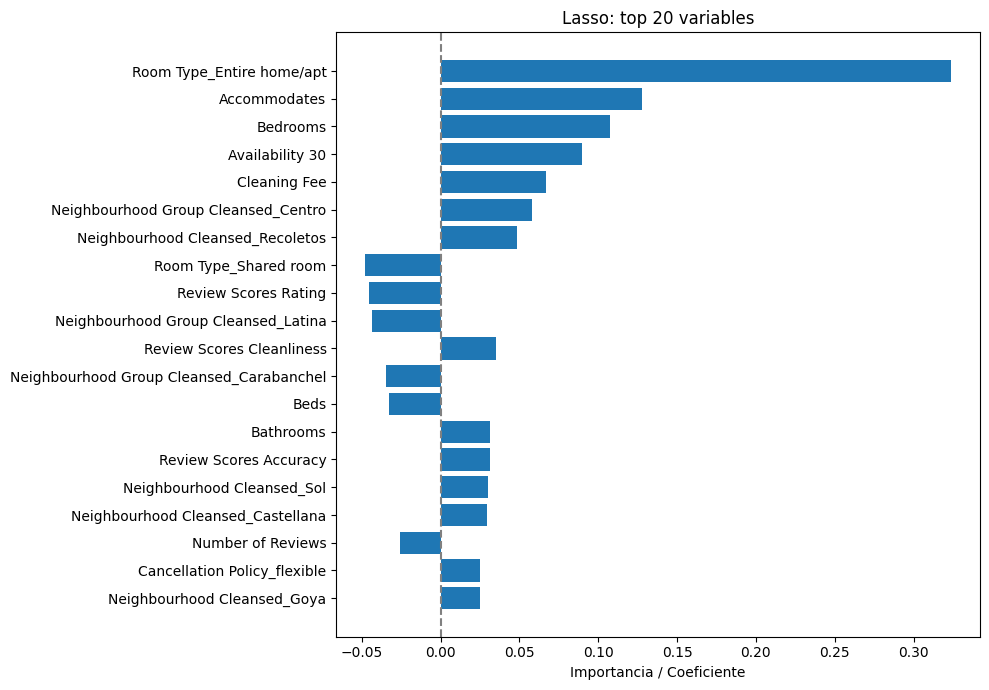

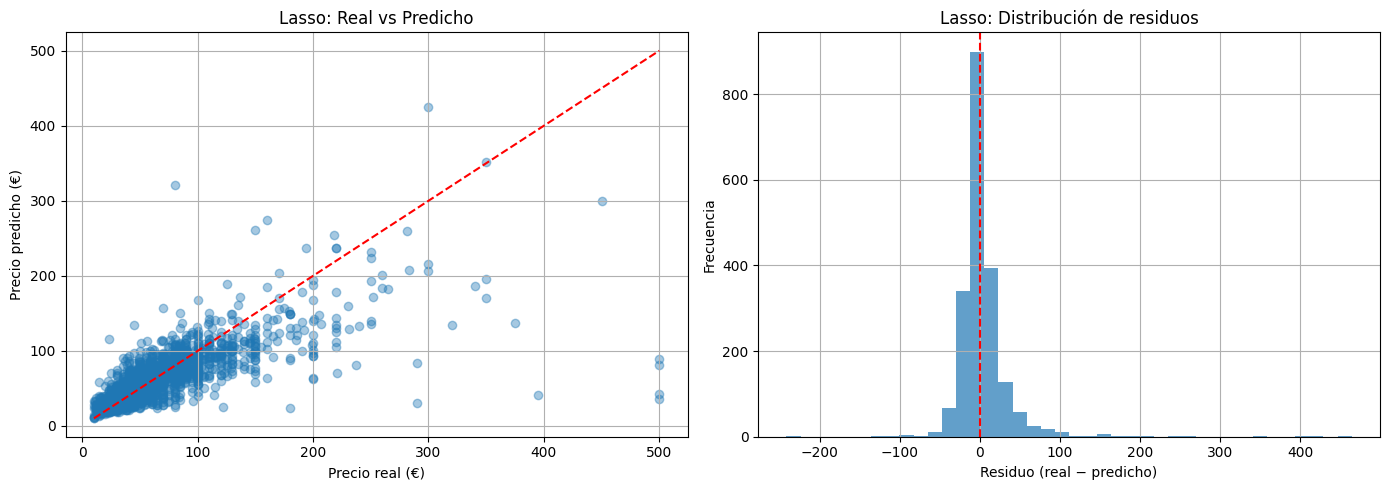

In [5]:
plot_importancia('Lasso', X_train.columns, best_lasso.coef_, figures_dir=FIGURES_DIR)
plot_resultados('Lasso', np.expm1(y_val), np.expm1(best_lasso.predict(X_val)), figures_dir=FIGURES_DIR)

## 3 · Ridge

Ridge también penaliza los coeficientes, pero en lugar de llevarlos a cero los reduce.
Conserva todas las variables pero con menos influencia.

In [6]:
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]}

grid_ridge = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    param_grid_ridge,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_
print(f'Mejor alpha: {grid_ridge.best_params_["alpha"]}')
print()

metricas('Ridge',
         np.expm1(y_train), np.expm1(best_ridge.predict(X_train)),
         np.expm1(y_val),   np.expm1(best_ridge.predict(X_val)))
guardar_modelo(best_ridge, MODELS_DIR / 'ridge.joblib')

Mejor alpha: 100

─── Ridge ───
  Train → RMSE:  34.69 €  |  MAE:  17.22 €  |  R²: 0.6100
  Val   → RMSE:  34.82 €  |  MAE:  17.63 €  |  R²: 0.5448

Modelo guardado en C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\ridge.joblib


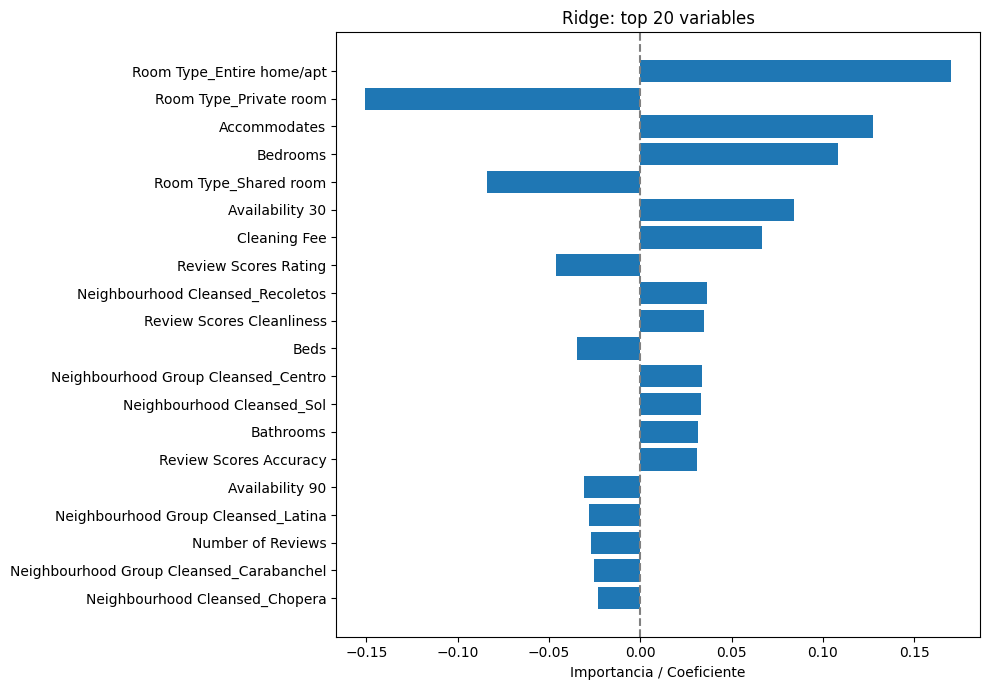

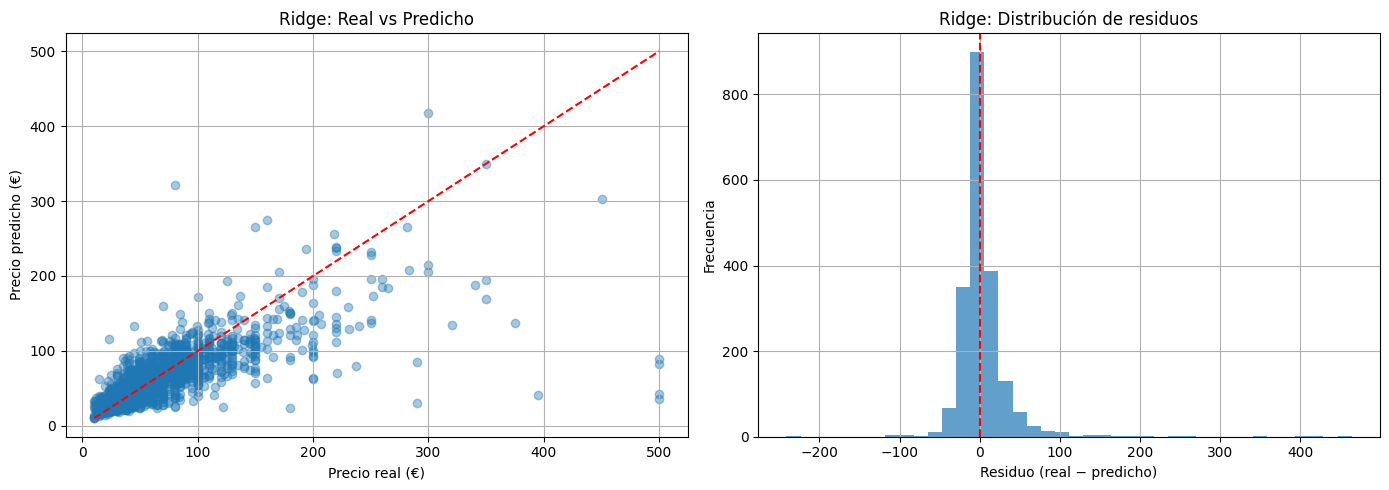

In [7]:
plot_importancia('Ridge', X_train.columns, best_ridge.coef_, figures_dir=FIGURES_DIR)
plot_resultados('Ridge', np.expm1(y_val), np.expm1(best_ridge.predict(X_val)), figures_dir=FIGURES_DIR)

## 4 · Random Forest

Un Random Forest entrena cientos de árboles de decisión, cada uno con una muestra
aleatoria de los datos. La predicción final es la media de todos los árboles.
Es más potente que los modelos lineales, pero puede sobreajustarse.

In [8]:
param_grid_rf = {
    'max_depth': range(3, 20),
    'min_samples_leaf': [5, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(
        n_estimators=300,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid_rf,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(f'Mejores parámetros: {grid_rf.best_params_}')
print()

metricas('Random Forest',
         np.expm1(y_train), np.expm1(best_rf.predict(X_train)),
         np.expm1(y_val),   np.expm1(best_rf.predict(X_val)))
guardar_modelo(best_rf, MODELS_DIR / 'random_forest.joblib')

Fitting 5 folds for each of 51 candidates, totalling 255 fits
Mejores parámetros: {'max_depth': 18, 'min_samples_leaf': 5}

─── Random Forest ───
  Train → RMSE:  35.94 €  |  MAE:  15.68 €  |  R²: 0.5814
  Val   → RMSE:  35.25 €  |  MAE:  17.09 €  |  R²: 0.5337

Modelo guardado en C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\random_forest.joblib


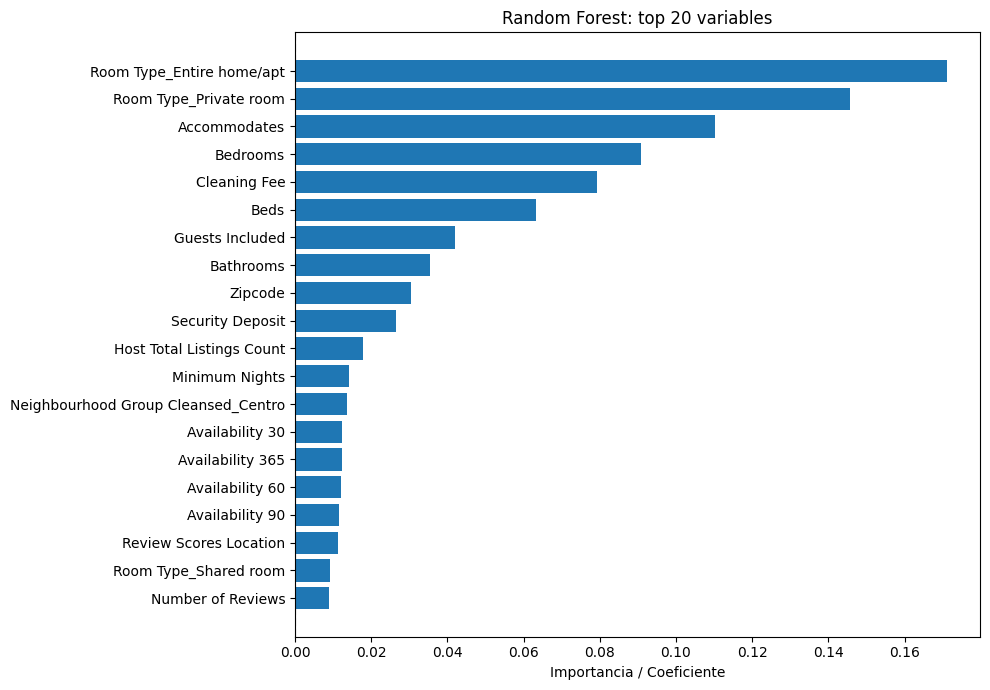

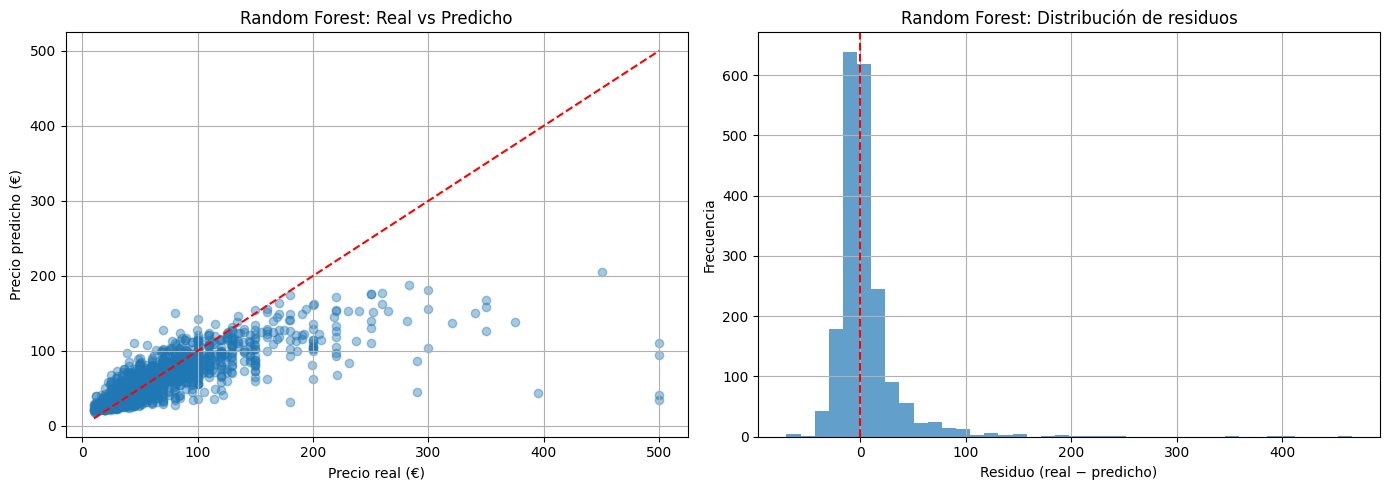

In [9]:
plot_importancia('Random Forest', X_train.columns, best_rf.feature_importances_, figures_dir=FIGURES_DIR)
plot_resultados('Random Forest', np.expm1(y_val), np.expm1(best_rf.predict(X_val)), figures_dir=FIGURES_DIR)

## 5 · ElasticNet

ElasticNet combina las penalizaciones de Lasso y Ridge en un solo modelo.
El parámetro `l1_ratio` controla el equilibrio: 0 = Ridge puro, 1 = Lasso puro.

Puede superar a ambos por separado cuando hay grupos de variables correlacionadas,
ya que Lasso tiende a elegir solo una de ellas mientras que ElasticNet conserva todo el grupo.

In [10]:
param_grid_en = {
    'alpha':    [0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.2, 0.5, 0.8]
}

grid_en = GridSearchCV(
    ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    param_grid_en,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
grid_en.fit(X_train, y_train)

best_en = grid_en.best_estimator_
print(f'Mejor alpha: {grid_en.best_params_["alpha"]}  |  Mejor l1_ratio: {grid_en.best_params_["l1_ratio"]}')
print(f'Variables seleccionadas (coef ≠ 0): {(best_en.coef_ != 0).sum()}')
print()

metricas('ElasticNet',
         np.expm1(y_train), np.expm1(best_en.predict(X_train)),
         np.expm1(y_val),   np.expm1(best_en.predict(X_val)))
guardar_modelo(best_en, MODELS_DIR / 'elasticnet.joblib')

Mejor alpha: 0.01  |  Mejor l1_ratio: 0.2
Variables seleccionadas (coef ≠ 0): 152

─── ElasticNet ───
  Train → RMSE:  34.86 €  |  MAE:  17.28 €  |  R²: 0.6061
  Val   → RMSE:  34.95 €  |  MAE:  17.66 €  |  R²: 0.5416

Modelo guardado en C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\elasticnet.joblib


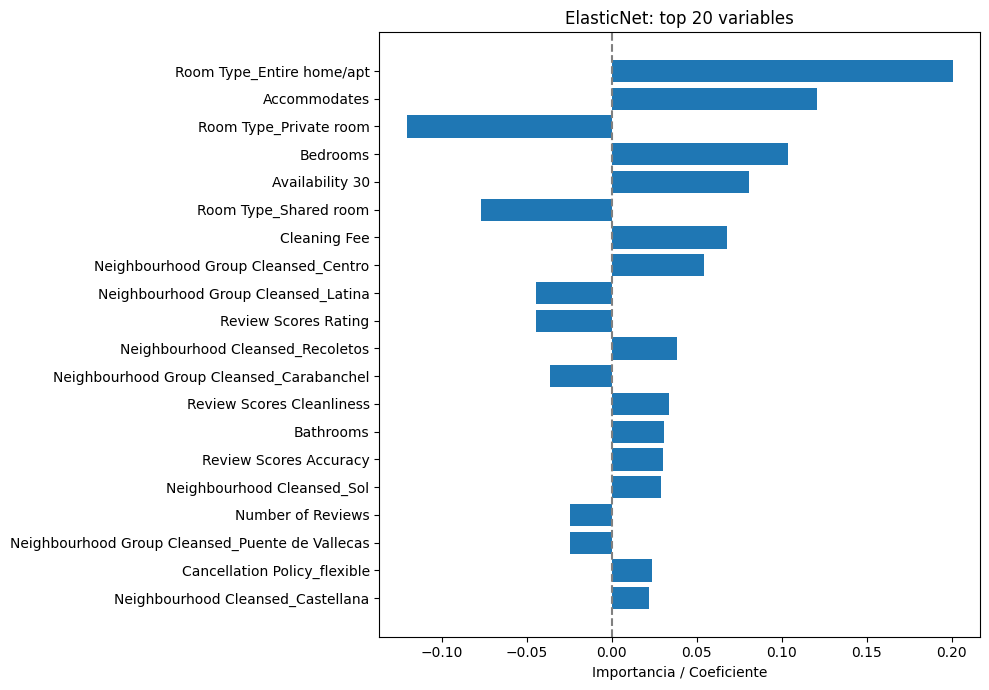

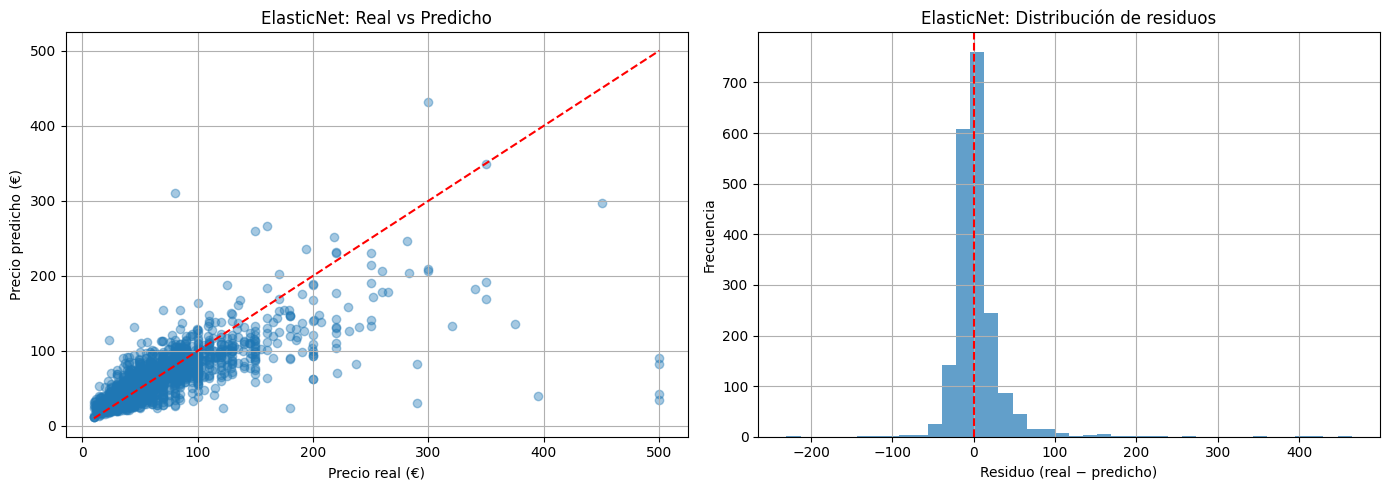

In [11]:
plot_importancia('ElasticNet', X_train.columns, best_en.coef_, figures_dir=FIGURES_DIR)
plot_resultados('ElasticNet', np.expm1(y_val), np.expm1(best_en.predict(X_val)), figures_dir=FIGURES_DIR)

## 6 · Gradient Boosting

El Gradient Boosting construye árboles de decisión de forma **secuencial**: cada árbol
nuevo se entrena para corregir los errores del anterior. Es más lento de entrenar que
Random Forest (que entrena todos los árboles en paralelo), pero suele generalizar mejor.

- `n_estimators`: número de árboles (más = mejor, pero más lento y riesgo de sobreajuste)
- `max_depth`: profundidad de cada árbol individual (valores bajos, 3-5, funcionan bien)
- `learning_rate`: cuánto "aprende" cada árbol nuevo (valores pequeños + más árboles = mejor)

In [12]:
param_grid_gb = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid_gb,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print(f'Mejores parámetros: {grid_gb.best_params_}')
print()

metricas('Gradient Boosting',
         np.expm1(y_train), np.expm1(best_gb.predict(X_train)),
         np.expm1(y_val),   np.expm1(best_gb.predict(X_val)))
guardar_modelo(best_gb, MODELS_DIR / 'gradient_boosting.joblib')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

─── Gradient Boosting ───
  Train → RMSE:  23.31 €  |  MAE:  12.07 €  |  R²: 0.8239
  Val   → RMSE:  31.10 €  |  MAE:  15.22 €  |  R²: 0.6369

Modelo guardado en C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\gradient_boosting.joblib


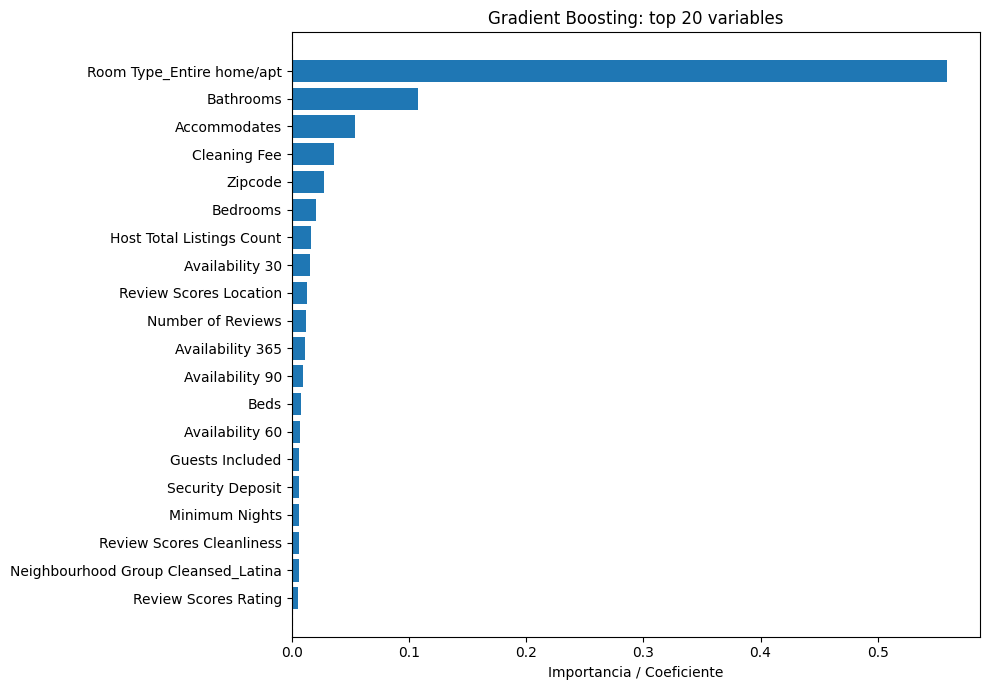

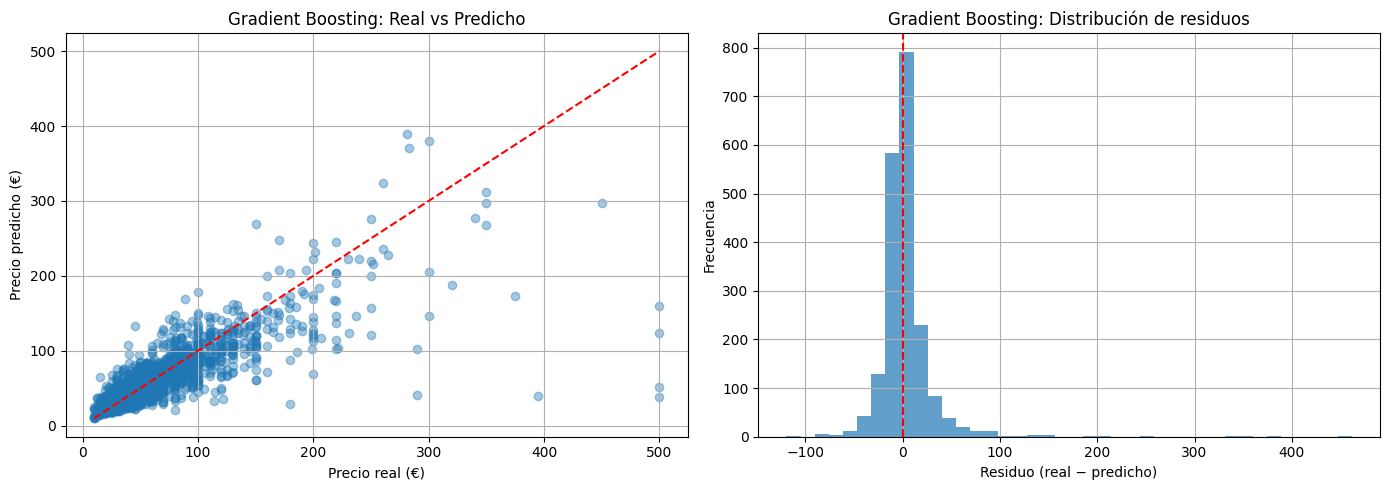

In [13]:
plot_importancia('Gradient Boosting', X_train.columns, best_gb.feature_importances_, figures_dir=FIGURES_DIR)
plot_resultados('Gradient Boosting', np.expm1(y_val), np.expm1(best_gb.predict(X_val)), figures_dir=FIGURES_DIR)

## 7 · Curvas de aprendizaje

Las curvas de aprendizaje muestran cómo evoluciona el error a medida que el modelo
ve más datos de entrenamiento. Sirven para diagnosticar dos problemas típicos:

- **Sobreajuste (overfitting):** la curva de train es mucho mejor que la de validación.
  El modelo ha "memorizado" los datos de entrenamiento pero no generaliza bien.
- **Subajuste (underfitting):** ambas curvas convergen en un error alto.
  El modelo es demasiado simple para capturar los patrones del problema.

El ideal es que ambas curvas converjan en un error bajo.

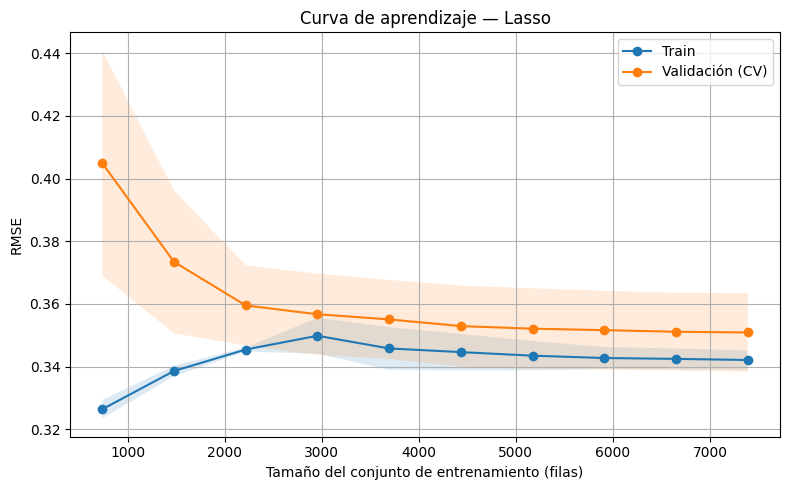

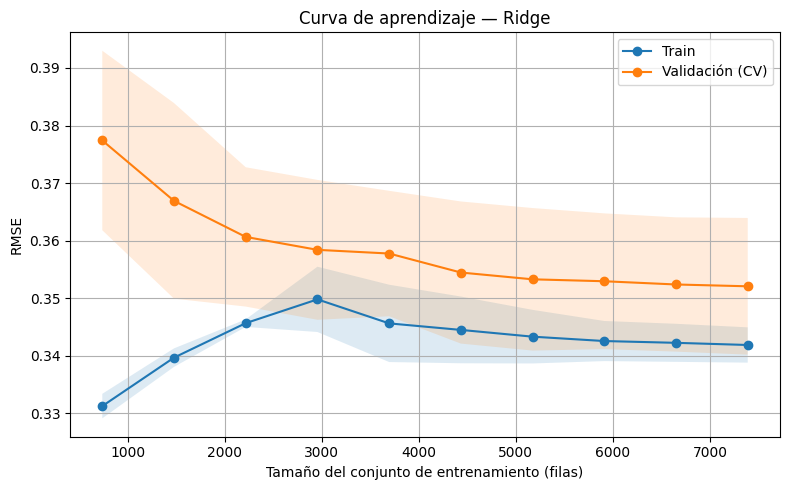

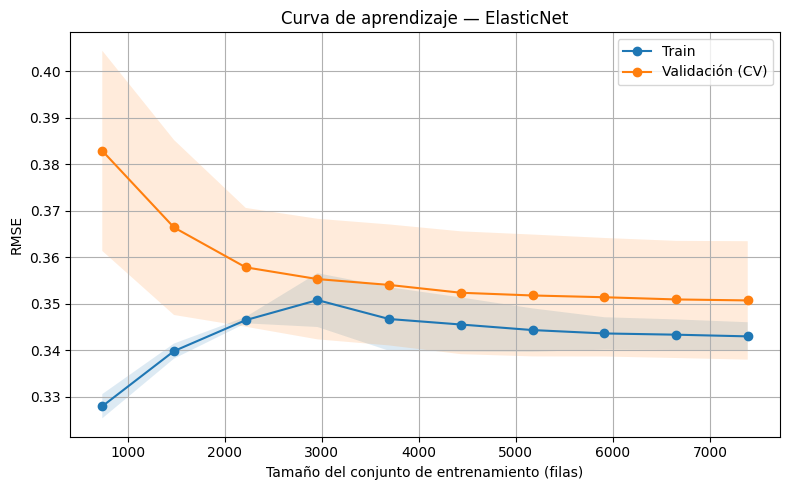

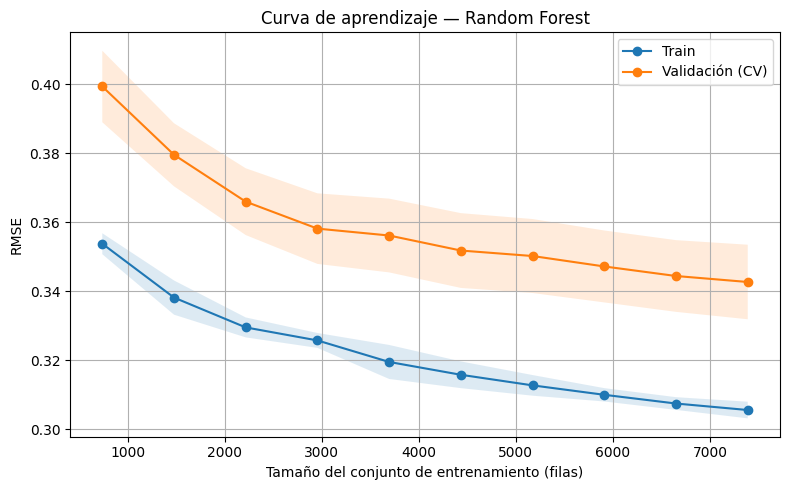

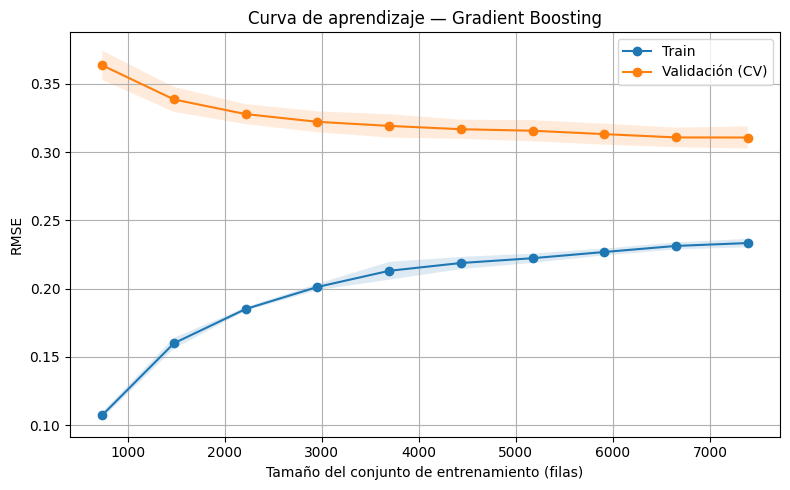

In [14]:
modelos_curvas = {
    'Lasso':             best_lasso,
    'Ridge':             best_ridge,
    'ElasticNet':        best_en,
    'Random Forest':     best_rf,
    'Gradient Boosting': best_gb,
}

for nombre, modelo in modelos_curvas.items():
    plot_curva_aprendizaje(nombre, modelo, X_train, y_train, figures_dir=FIGURES_DIR)